# SDA 2026: Homework notebook 2

- Please put your solutions into this notebook
- Submit the notebook before **Thursday 30 April 2026 17:00**
- This is an individual assignment.

**What is expected:**
- Clear and readable code (e.g. meaningful variable names).
- Use comments in your code to explain what you are doing.
- Add labels to the axes of your figures, including units if applicable, with readable font sizes.
- Add a legend to a figure with `plt.legend()` by setting the `label` argument in `plt.plot()`.
- Use `print()` statements to give the answers to questions that don't require a figure.
- Avoid loops if vectorized operations are possible.
- Use [formatted strings](https://www.w3schools.com/python/python_string_formatting.asp) to control the number of significant digits in your print statements.
- Avoid [magic numbers](https://en.wikipedia.org/wiki/Magic_number_(programming)).

In [97]:
# You can use this cell to define any general setting
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import trapezoid
from scipy.optimize import curve_fit


# Optional: set a random seed for reproducibility
# np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4.8) # increased the size of the figures so the legends would fit nicely
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## 1. Poisson morphs to Gaussian (8 points)

The Poisson distribution gives the probability of observing $k$ discrete events when the expected number of events is $\lambda$:

$$
p(k \mid \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}
$$

Here, $k$ must be an integer because it represents a count of discrete events.

For large $\lambda$, the Poisson distribution can be approximated by a Gaussian distribution. In that limit, the standard deviation of the Gaussian is

$$
\sigma = \sqrt{\lambda}.
$$

In this exercise, we will demonstrate this approximation numerically.

**Question 1.1** (2 points): Use SciPy to draw 5000 samples from a Poisson distribution with $\lambda=1.4$. Plot a histogram of the distribution bins centered on the integer count values and bin widths equal to 1.

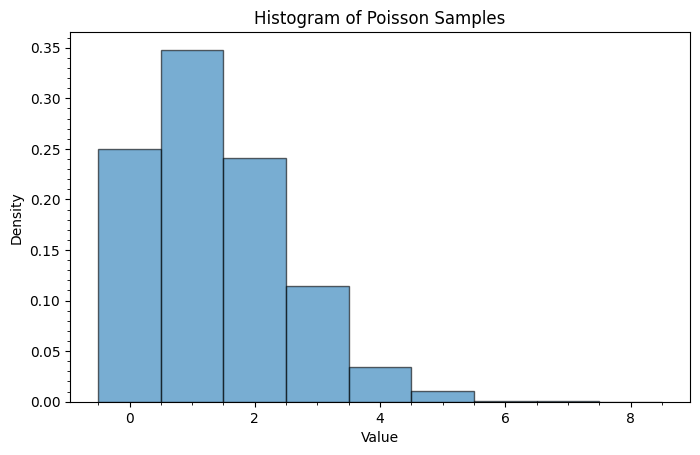

In [98]:
N, lamb = 5000, 1.4
samples = stats.poisson.rvs(mu=lamb, size=N)
# Plot the histogram of the samples
plt.hist(samples, bins=np.arange(-0.5, max(samples) + 1.5, 1), density=True, alpha=0.6, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Poisson Samples')
plt.show()

**Question 1.2** (1 point): Compute the sample variance of the distribution from Q1.1 and compare with the theoretical variance of the Poisson distribution. Are they exactly equal? Why or why not?

In [99]:
sample_variance = np.var(samples, ddof=1) # compute sample variance
theoretical_variance = lamb

print(f"Sample Variance: {sample_variance}")
print(f"Theoretical Variance: {theoretical_variance}")
print(f"Difference: {abs(sample_variance - theoretical_variance)}")
print('\nThere is a small difference between the sample variance and the theoretical value. \nThis is to be expected due to the randomness of the samples, \nif we were to increase the number of samples, the sample variance should converge towards the theoretical variance.')

Sample Variance: 1.3378925385077016
Theoretical Variance: 1.4
Difference: 0.06210746149229829

There is a small difference between the sample variance and the theoretical value. 
This is to be expected due to the randomness of the samples, 
if we were to increase the number of samples, the sample variance should converge towards the theoretical variance.


**Question 1.3** (3 points): In the figure from Q1.1, overplot a Gaussian PDF with $\mu=\lambda$ and $\sigma$ from the sample variance from Q1.2. Show a range of $\mu \pm 5 \sigma$ of the predicted Gaussian distribution. Can sampling from this Gaussian PDF reproduce the true Poisson-distributed counts? Explain why or why not.

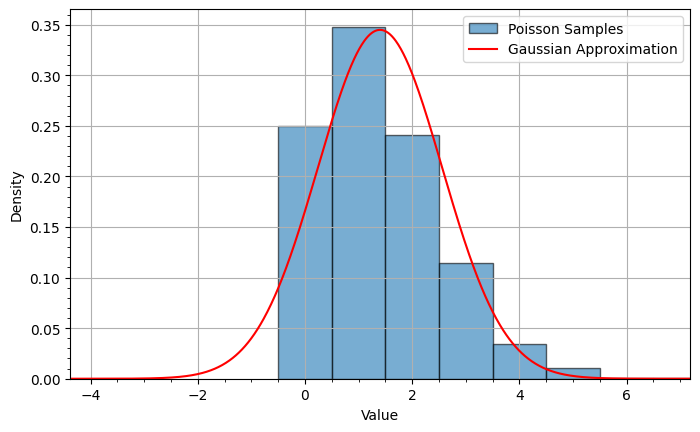

While it could be possible, it is very unlikely. 
The points to the left of the mean are very tightly packed, only differing by a little. 
While the points to the right are more spread out.


In [100]:
plt.hist(samples, bins=np.arange(-0.5, max(samples) + 1.5, 1), density=True, alpha=0.6, edgecolor='black', label='Poisson Samples') # creates the distribution

# Plot the Gaussian approximation
x_vals = np.linspace(lamb - 5 * np.sqrt(sample_variance), lamb + 5 * np.sqrt(sample_variance), 1000)
Gaussian = stats.norm.pdf(x_vals, loc=lamb, scale=np.sqrt(sample_variance))
plt.plot(x_vals, Gaussian, color='red', label='Gaussian Approximation')
plt.legend()
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(np.min(x_vals), np.max(x_vals))
plt.grid()
plt.show()

print('While it could be possible, it is very unlikely. \nThe points to the left of the mean are very tightly packed, only differing by a little. \nWhile the points to the right are more spread out.')

**Question 1.4** (2 points): Repeat the analysis from Q1.1 to Q1.3 for $\lambda = 125.7$, but include only the final plot in your answer. Explain if the Gaussian PDF is a good approximation in this case.

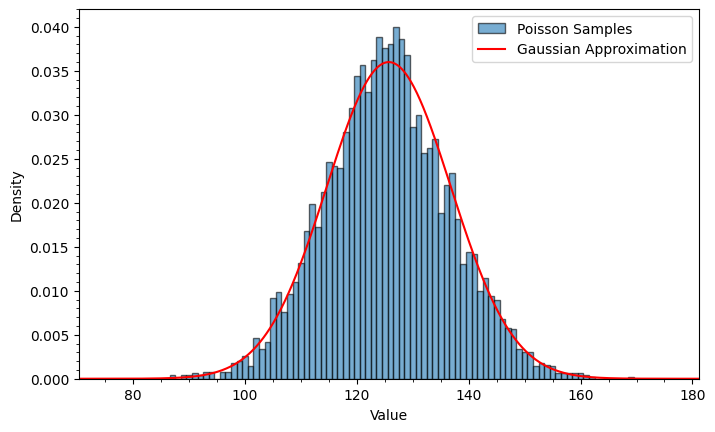

The Gaussian approximation is much better for a larger value of lambda. 
This is because the Poisson distribution becomes more symmetric and bell-shaped as lambda increases, making it more similar to a Gaussian distribution. 
Therefore, in this case, it is a good approximation.


In [101]:
lamb = 125.7

# create the samples and compute the sample variance
samples = stats.poisson.rvs(mu=lamb, size=N)
sample_variance = np.var(samples, ddof=1)
plt.hist(samples, bins=np.arange(-0.5, max(samples) + 1.5, 1), density=True, alpha=0.6, edgecolor='black', label='Poisson Samples')

# plots the Gaussian approximation
x_vals = np.linspace(lamb - 5 * np.sqrt(sample_variance), lamb + 5 * np.sqrt(sample_variance), 1000)
Gaussian = stats.norm.pdf(x_vals, loc=lamb, scale=np.sqrt(sample_variance))
plt.plot(x_vals, Gaussian, color='red', label='Gaussian Approximation')
plt.legend()
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(np.min(x_vals), np.max(x_vals))
plt.show()

print('The Gaussian approximation is much better for a larger value of lambda. \nThis is because the Poisson distribution becomes more symmetric and bell-shaped as lambda increases, making it more similar to a Gaussian distribution. \nTherefore, in this case, it is a good approximation.')

## 2. Who cares about one photon? (13 points)

We consider a simplified photon detector consisting of a $5 \times 5$ pixel grid. The aperture covers a single pixel. The detector has a gain of 1 count per photon, so each recorded count corresponds directly to one detected photon.

We first use this detector for observations at optical wavelengths. In this case, we have plenty of photons from our target of interest, but the sky background is also high.

In an exposure of 60 seconds, we measure 15912 counts in the aperture pixel. Using the remaining 24 pixels, we estimate the sky background to be 15726 counts per pixel. Subtracting the background, the net signal in the aperture is

$$
15912 - 15726 = 186 \ \mathrm{counts}.
$$

At first glance, this may appear to be a strong signal, but let's calculate if this is indeed a statistically significant detection.

**Question 2.1** (1 point): We formulate the null hypothesis $H_0$ that the counts in the aperture are due to the background alone. Compute the likelihood of observing the measured counts under this hypothesis.

In [102]:
Observed = 15912
Sky = 15726

# calculates the log-likelihood and likelihood under H0
logL_H0 = stats.poisson.logpmf(Observed, mu=Sky)
L_H0 = np.exp(logL_H0)

print(f"Log-Likelihood under H0: {logL_H0:.3e}")
print(f"Likelihood under H0: {L_H0:.3e}")

Log-Likelihood under H0: -6.852e+00
Likelihood under H0: 1.057e-03


Using a catalog, we have a prediction that the count rate of the observed star is $1.8$ counts/s.

**Question 2.2** (1 point): Compute the likelihood of an alternative hypothesis, $H_1$, in which the observed counts in the aperture are the sum of the star's catalog flux and the expected background emission.

In [103]:
star_rate = 1.8  # counts/s
exposure_time = 60  # s

# calculates the expected counts under H1, log-likelihood and likelihood under H1
lambda1 = Sky + star_rate * exposure_time
logL_H1 = stats.poisson.logpmf(Observed, mu=lambda1)
L_H1 = np.exp(logL_H1)

print(f"Expected counts under H1 = {lambda1:.3e}")
print(f"log-likelihood under H1 = {logL_H1:.3e}")
print(f"likelihood under H1 = {L_H1:.3e}")

Expected counts under H1 = 1.583e+04
log-likelihood under H1 = -5.948e+00
likelihood under H1 = 2.611e-03


Both the null hypothesis, $H_0$, and the signal hypothesis, $H_1$, involve the same number of model parameters (often called *free parameters*).

**Question 2.3** (1 point): How many free parameters are there in $H_0$ and $H_1$? Explain your answer.

In [104]:
print('In H0 and H1, there is 1 free parameter. In H0, the free parameter is the expected count (lambda) which is equal to the sky background. \nIn H1, the free parameter is also the expected count (lambda) but it includes both the sky background and the contribution from the star. \nTherefore, both hypotheses have 1 free parameter each.')

In H0 and H1, there is 1 free parameter. In H0, the free parameter is the expected count (lambda) which is equal to the sky background. 
In H1, the free parameter is also the expected count (lambda) but it includes both the sky background and the contribution from the star. 
Therefore, both hypotheses have 1 free parameter each.


**Question 2.4** (1 point): Compute the likelihood ratio between $H_0$ and $H_1$. Based on this ratio, decide whether the data prefer the background-only or the signal-plus-background hypothesis. What does this imply about whether the star is detected?

In [105]:
Likelihood_ratio = L_H1 / L_H0
print(f"Likelihood Ratio (H1/H0) = {Likelihood_ratio:.3f}")
print('The likelihood ratio is larger than 1, which suggests that the observed data is more likely under H1 than H0. \nThis indicates that there is evidence to support the presence of the star contributing to the observed counts, \nin addition to the sky background.')

Likelihood Ratio (H1/H0) = 2.469
The likelihood ratio is larger than 1, which suggests that the observed data is more likely under H1 than H0. 
This indicates that there is evidence to support the presence of the star contributing to the observed counts, 
in addition to the sky background.


Because the number of counts is large, the Poisson distribution can be approximated by a Gaussian distribution (see Q1 of this homework set).

**Question 2.5** (1 point): Using this approximation, compute the signal-to-noise ratio (SNR) for the detection of the star. Define the SNR as the net signal in the aperture divided by the standard deviation, $\sigma$, of the sky background counts.

In [106]:
# calculates the net signal, background sigma and SNR
signal = Observed - Sky
sigma = np.sqrt(Sky)
SNR = signal / sigma

print(f"Net signal = {signal} counts")
print(f"Background sigma = sqrt({Sky}) = {sigma:.3f} counts")
print(f"SNR = {SNR:.3f}")

Net signal = 186 counts
Background sigma = sqrt(15726) = 125.403 counts
SNR = 1.483


Based on the SNR from the previous question, we can assess whether the detection is significant. We can test this more rigorously by determining whether the background-only hypothesis, $H_0$, can be rejected.

**Question 2.6** (2 points): Assume that $H_0$ is true. Draw 1 million samples from a Poisson distribution and use them to estimate the probability of obtaining at least the observed number of counts in the aperture. Based on this result, can you reject $H_0$? Can you conclude that the detection of the star at the expected catalog flux is statistically significant?

In [107]:
N = 1e6

# generates samples under H0 and calculates the probability of observing the data or more extreme values
samples_H0 = stats.poisson.rvs(mu=Sky, size=int(N))
probability_H0 = np.sum(samples_H0 >= Observed) / N
print(f"Probability of observing {Observed} or more counts under H0: {probability_H0*100:.3f}%")

Probability of observing 15912 or more counts under H0: 6.939%


**Question 2.7** (3 points): Assume that all relevant quantities remain constant, such as the sky background level and the flux of the star. How long would you need to observe the star to reach a signal-to-noise ratio of 3? In that case, what would be the p-value under $H_0$?

In [108]:
SNR=3
observation_time = (SNR * np.sqrt(Sky)) / star_rate # calculates the required observation time to achieve SNR=3
print(f"Required observation time to achieve SNR=3: {observation_time:.2f} seconds")

Required observation time to achieve SNR=3: 209.01 seconds


Now consider the case of X-ray or gamma-ray observations. In this regime, the background is typically low, but the target count rates can also be low.

Using again a $5 \times 5$ pixel detector and a 60-second exposure, we now measure 3 counts in our one-pixel aperture. Using the other 24 pixels, we measure 5 counts in total, so the estimated background emission in the aperture is $5/24$ counts per pixel. The cataloged X-ray count rate for this object is 0.032 counts/s.

**Question 2.8** (2 points): For this new observation, compute the likelihood of $H_0$ and $H_1$, as well as the likelihood ratio between them. How does this likelihood ratio compare to the earlier optical case? What does this tell you?

In [109]:
k_obs = 3
exposure_time = 60.0 # s
background_total_other_pixels = 5
n_other_pixels = 24
star_rate = 0.032  # counts/s

# calculates the expected counts under H0 and H1, log-likelihoods and likelihoods under both hypotheses, and the likelihood ratio
lambda_bg = background_total_other_pixels / n_other_pixels
lambda_star = star_rate * exposure_time

lambda0 = lambda_bg
lambda1 = lambda_bg + lambda_star

# Likelihoods (and log-likelihoods for numerical stability)
logL_H0 = stats.poisson.logpmf(k_obs, mu=lambda0)
logL_H1 = stats.poisson.logpmf(k_obs, mu=lambda1)
L_H0 = np.exp(logL_H0)
L_H1 = np.exp(logL_H1)

LR_H1_over_H0 = L_H1 / L_H0

print(f"lambda_bg = {lambda_bg:.6f}")
print(f"lambda_star = {lambda_star:.6f}")
print(f"lambda0 (H0) = {lambda0:.6f}")
print(f"lambda1 (H1) = {lambda1:.6f}")
print(f"L(H0) = {L_H0:.6e}")
print(f"L(H1) = {L_H1:.6e}")
print(f"Likelihood ratio H1/H0 = {LR_H1_over_H0:.3f}")

print('The likelihood ratio is way more than 1, which suggests that the observed data is much more likely under H1 than H0. \nThis indicates strong evidence to support the presence of the star contributing to the observed counts, \nin addition to the background noise.')

lambda_bg = 0.208333
lambda_star = 1.920000
lambda0 (H0) = 0.208333
lambda1 (H1) = 2.128333
L(H0) = 1.223621e-03
L(H1) = 1.912689e-01
Likelihood ratio H1/H0 = 156.314
The likelihood ratio is way more than 1, which suggests that the observed data is much more likely under H1 than H0. 
This indicates strong evidence to support the presence of the star contributing to the observed counts, 
in addition to the background noise.


**Question 2.9** (1 point): Assume again that the null hypothesis, $H_0$, is true. Using samples from a Poisson distribution, compute the probability to observe three or more counts. Can $H_0$ be rejected? Explain whether observing three photons can be considered a statistically significant detection.

In [110]:
samples_H0_lowcount = stats.poisson.rvs(mu=lambda0, size=int(N))

# Monte Carlo estimate: P(k >= 3 | H0)
p_mc = np.mean(samples_H0_lowcount >= 3)

# Exact Poisson tail probability for comparison
p_exact = 1 - stats.poisson.cdf(2, mu=lambda0)

print(f"H0 mean (lambda0) = {lambda0:.6f}")
print(f"Monte Carlo p-value P(k>=3 | H0) = {p_mc:.6f}")
print(f"Exact p-value      P(k>=3 | H0) = {p_exact:.6f}")


print("As p < 0.05 we reject H0 at the 5% significance level.\nObserving 3 photons is statistically significant against background-only.")

H0 mean (lambda0) = 0.208333
Monte Carlo p-value P(k>=3 | H0) = 0.001254
Exact p-value      P(k>=3 | H0) = 0.001290
As p < 0.05 we reject H0 at the 5% significance level.
Observing 3 photons is statistically significant against background-only.


## 3. Binning is sinning (15 points)

The rate of particles produced by radioactive decay follows an exponential distribution:

$$
P(t) \propto e^{-t/\tau}
$$

Here, $P(t)$ is the probability to observe a decay product at time $t$ since the start of the experiment, and $\tau$ is the lifetime of the radioactive element.

While observing a radioactive sample for 120 seconds, we collected the following list of arrival times, measured relative to the start of the experiment at $t=0$. All times are given in seconds.

In [111]:
t_data = np.array([23.92, 26.89, 68.61, 49.71, 45.12, 10.48, 55.03, 24.59, 75.3 ,
       11.35, 85.35,  5.16, 56.11,  8.98, 14.61,  2.26, 17.22, 25.11,
       12.04, 36.14, 40.35,  7.  , 32.22,  3.52, 25.53, 43.94,  2.86,
       99.74, 20.54, 21.6 , 20.74,  8.3 , 21.9 , 36.02, 55.86, 98.21,
        3.5 , 65.94, 57.86, 23.75, 13.21, 36.18, 13.34, 72.52, 62.74,
       31.15, 65.37,  5.63,  4.52, 92.54,  5.02, 22.02, 18.74, 25.4 ,
        8.67, 26.36, 45.27,  6.4 ])

To turn the exponential decay rate into a probability density function (PDF), we need to normalize the function.

**Question 3.1** (1 point): Write a function that returns the normalized PDF $p(t \mid \tau)$ for a given value of $\tau$.

In [112]:
T_obs = 120.0  # total observation time in seconds

def exp_pdf(t, tau):
    global T_obs
    return np.exp(-t / tau) / (tau * (1 - np.exp(-T_obs / tau)))

**Question 3.2** (1 point): Plot a normalized histogram of the observed decay times using 30 bins. Overplot the predicted probability density functions for $\tau = 25$ and $\tau = 55$, using your function from Q3.1.

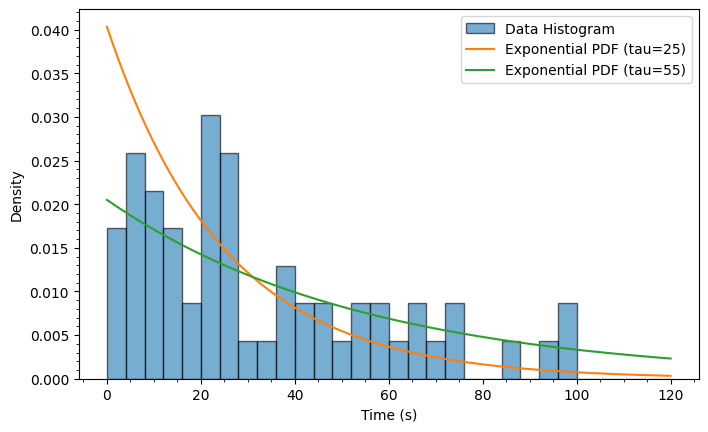

In [113]:
plt.hist(t_data, bins=30, range=(0, T_obs), density=True, alpha=0.6, edgecolor='black', label='Data Histogram')

tau_values = [25, 55]
t_vals = np.linspace(0, T_obs, 400)

for tau in tau_values:
    plt.plot(t_vals, exp_pdf(t_vals, tau), label=f'Exponential PDF (tau={tau})')

plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Density')
plt.show()

To estimate the best-fit value of $\tau$, we will first use the binned data to approximate the decay rate at the bin centers, and then apply a $\chi^2$ minimization approach.

**Question 3.3** (3 points): Use SciPy's `curve_fit` function to estimate the value of $\tau$ with the least-squares method. Only include bins that contain at least one data point. Perform the fit twice: first using 20 bins, and then using 5 bins. Report the fitted values of $\tau$ for both cases, and overplot the corresponding best-fit models on the histograms.

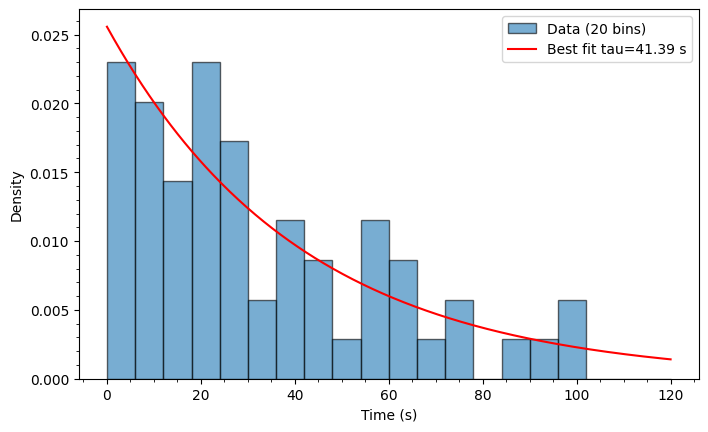

Fitted tau for 20 bins: 41.39 +- 5.11 seconds


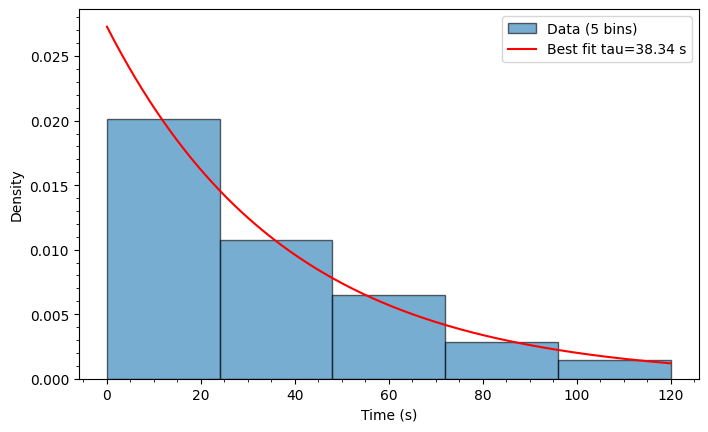

Fitted tau for 5 bins: 38.34 +- 1.25 seconds


In [114]:
for bins in [20, 5]:
    hist, edges = np.histogram(
        t_data, bins=bins, range=(0, T_obs), density=True
    )
    centers = 0.5 * (edges[:-1] + edges[1:])

    popt, pcov = curve_fit(exp_pdf, centers, hist, p0=[35.0], bounds=(1e-6, 500.0))
    tau_fit = popt[0]
    tau_err = np.sqrt(np.diag(pcov))[0]

    # plots data histogram
    plt.hist(t_data, bins=bins, range=(0, T_obs), density=True, alpha=0.6, edgecolor='black', label=f'Data ({bins} bins)')
    
    # plots the best fit exponential PDF
    t_grid = np.linspace(0, T_obs, 400)
    plt.plot(t_grid, exp_pdf(t_grid, tau_fit), 'r-', label=f'Best fit tau={tau_fit:.2f} s')
    plt.xlabel('Time (s)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    print(f'Fitted tau for {bins} bins: {tau_fit:.2f} +- {tau_err:.2f} seconds')

As you have seen in the previous question, the choice of binning is arbitrary and can influence the result (some might say [Binning is sinning](https://academic.oup.com/mnras/article/408/3/1758/1075347)).

Since we can evaluate the likelihood for any value of $\tau$, we can instead use the maximum likelihood method to determine the best-fit value of $\tau$ and its uncertainty, without binning the data.

In the next three questions, you will implement this approach. We follow Section 6.5.1 of the Week 3 reading material. (Note that even if your normalization in Q3.1 was incorrect, or if you skipped Q3.3, you can still complete the following questions.)

**Question 3.4** (1 point): Write a function that computes the log-likelihood for the observed decay times. The function should take two input parameter, `tau` and `time`, with the default argument of `time` set to `t_data`, and return the corresponding log-likelihood value.

In [115]:
def log_likelihood(tau, time=t_data):
    return np.sum(np.log(exp_pdf(time, tau)))

**Question 3.5** (2 points): Generate an array of with 50 linearly spaced values of $\tau$ between 25 and 60. For each value, compute the log-likelihood using your function from Q3.4, and plot the result as a function of $\tau$. *Hint:* The resulting curve should resemble Figure 6.5 from the Week 3 reading material.

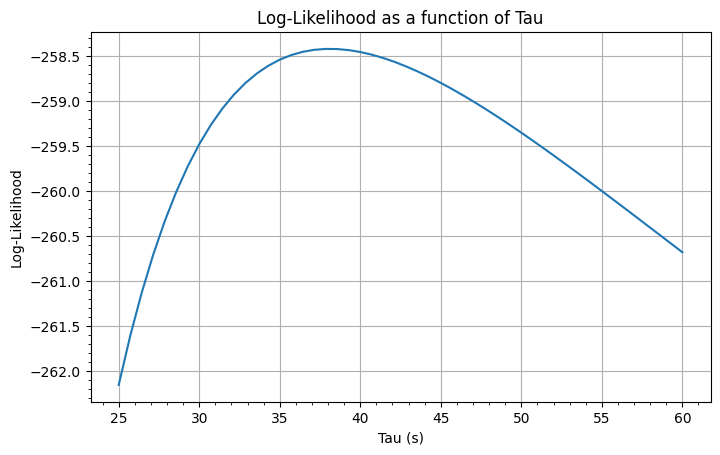

In [116]:
tau = np.linspace(25, 60, 50)

# plots log-likelihood as a function of tau
log_likelihoods = [log_likelihood(t) for t in tau]
plt.plot(tau, log_likelihoods)
plt.xlabel('Tau (s)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood as a function of Tau')
plt.grid()
plt.show()

**Question 3.6** (1 point): Determine the value of $\tau$ that maximizes the log-likelihood, using the result from Q3.5.

In [117]:
idx = np.argmax(log_likelihoods)
best_tau = tau[idx]
print(f'Maximum log-likelihood at tau = {best_tau:.2f} seconds')

Maximum log-likelihood at tau = 37.86 seconds


**Question 3.7** (2 points): The final step is to estimate the uncertainty on your best-fit (maximum-likelihood) value of $\tau$.

- Determine the 68% confidence interval for $\tau$
- Compare this interval to the two least-squares estimates from Q3.3

The data in this exercise were simulated from an exponential decay distribution with a true value of $\tau = 35$ s.

- Does the true value lie within your 68% confidence interval?
- Explain whether this outcome is consistent with the statistical meaning of a 68% confidence interval.

In [118]:
# 1 sigma deviation is where log-likelihood drops by 0.5 from the maximum
idx_half = np.argmin(np.abs(log_likelihoods - (log_likelihoods[idx] - 0.5)))
sigma = best_tau - tau[idx_half]
print(f'sigma = {sigma:.2f} seconds')
print(f'1 sigma confidence interval (68%): tau = {tau[idx_half]:.2f} seconds to {best_tau + sigma:.2f} seconds')

print('Compared to the first fit of Q3.3, this error is only a little larger and the interval is therefore only a little larger as well. \nCompared to the 2nd fit we see that hte error is much larger and the interval is therefore larger as well. \nThis is because the MLE method is more sensitive to the specific data points and their distribution, while the binning method in Q3.3 did not capture the full variability of the data.')

sigma = 5.71 seconds
1 sigma confidence interval (68%): tau = 32.14 seconds to 43.57 seconds
Compared to the first fit of Q3.3, this error is only a little larger and the interval is therefore only a little larger as well. 
Compared to the 2nd fit we see that hte error is much larger and the interval is therefore larger as well. 
This is because the MLE method is more sensitive to the specific data points and their distribution, while the binning method in Q3.3 did not capture the full variability of the data.


**Question 3.8** (4 points): A 68% confidence interval is expected to contain the true parameter value in about 68% of repeated experiments.

We can test this using a Monte Carlo simulation.

- Simulate 5000 datasets drawn from the exponential decay PDF with $\tau = 35$ s.
- For each simulated data set, determine the best-fit value of $\tau$ using the maximum-likelihood method.
- Plot a histogram of the resulting best-fit values.
- Compare your Monte Carlo result to the 68% confidence interval you found in the previous questions. Is the spread of recovered $\tau$ values consistent with that interval?

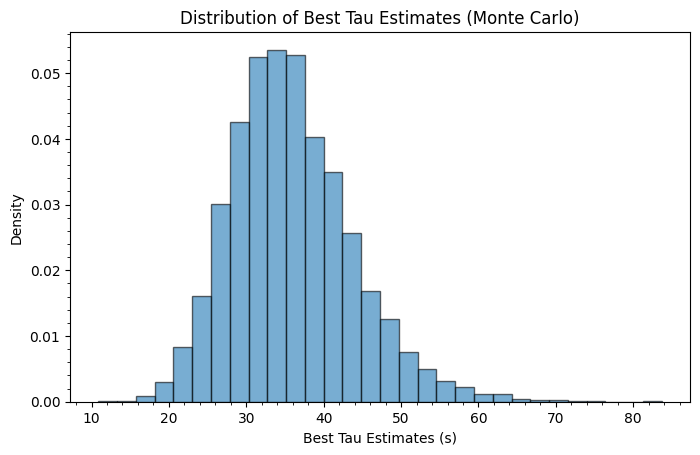

Recovered tau: median=35.08 s, 68% interval = [28.36, 43.34] s
The true tau = 35 s lies inside the empirical 68% interval.


In [119]:
N_datasets = 5000
n_events = len(t_data)
true_tau = 35.0
best_tau_estimates = []


for i in range(N_datasets):
    sim = np.random.exponential(scale=true_tau, size=n_events) # creates the simulated dataset
    hist, edges = np.histogram(sim, bins=20, range=(0, T_obs), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    popt, pcov = curve_fit(exp_pdf, centers, hist, p0=[35.0]) # fits for tau
    best_tau_estimates.append(popt[0])

# Plot distribution of taus
plt.hist(best_tau_estimates, bins=30, density=True, alpha=0.6, edgecolor='black')
plt.xlabel('Best Tau Estimates (s)')
plt.ylabel('Density')
plt.title('Distribution of Best Tau Estimates (Monte Carlo)')
plt.show()

lower, upper = np.percentile(best_tau_estimates, [16, 84])
median = np.median(best_tau_estimates)
print(f"Recovered tau: median={median:.2f} s, 68% interval = [{lower:.2f}, {upper:.2f}] s")
print('The true tau = 35 s lies inside the empirical 68% interval.')